In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_DIR = Path("../../milk10k_project")

df_metadata = pd.read_csv(DATA_DIR / "metadata.csv")
gt = pd.read_csv(DATA_DIR / "supplements" / "training_gt.csv")

CLASS_COLS = ["AKIEC", "BCC", "BEN_OTH", "BKL", "DF",
              "INF", "MAL_OTH", "MEL", "NV", "SCCKA"]

gt["diagnosis_class"] = gt[CLASS_COLS].idxmax(axis=1)

df = df_metadata.merge(gt[["lesion_id", "diagnosis_class"]], on="lesion_id", how="inner")
df.head()

,isic_id,attribution,copyright_license,age_approx,anatom_site_general,anatom_site_special,concomitant_biopsy,diagnosis_1,diagnosis_2,diagnosis_3,diagnosis_4,diagnosis_confirm_type,image_manipulation,image_type,lesion_id,melanocytic,sex,diagnosis_class
0,ISIC_0051817,MILK study team,CC-BY-NC,70.0,upper extremity,NaN,True,Malignant,Malignant epidermal proliferations,"Squamous cell carcinoma, Invasive",NaN,histopathology,instrument only,dermoscopic,IL_1612768,NaN,male,SCCKA
1,ISIC_0073863,MILK study team,CC-BY-NC,5.0,NaN,NaN,True,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Reed",histopathology,instrument only,dermoscopic,IL_2547802,True,female,NV
2,ISIC_0075884,MILK study team,CC-BY-NC,10.0,upper extremity,NaN,True,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Acral",histopathology,instrument only,clinical: close-up,IL_9270970,True,female,NV
3,ISIC_0076255,MILK study team,CC-BY-NC,50.0,head/neck,NaN,True,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,NaN,histopathology,instrument only,dermoscopic,IL_8089688,NaN,female,BCC
4,ISIC_0077054,MILK study team,CC-BY-NC,75.0,head/neck,NaN,True,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,NaN,histopathology,instrument only,dermoscopic,IL_5271098,NaN,male,BCC


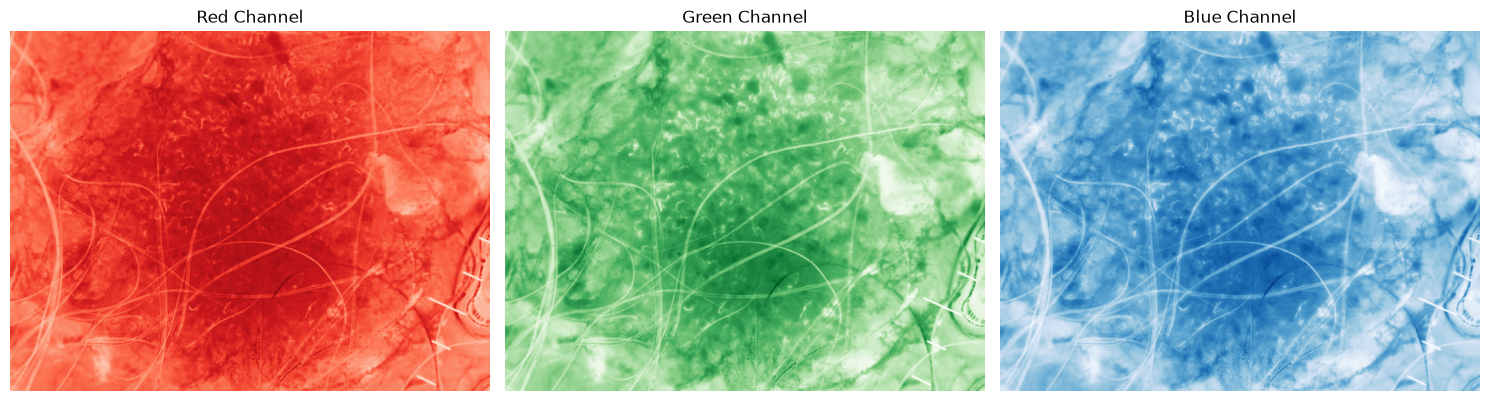

Mean intensity - Red: 133.99
Mean intensity - Green: 94.37
Mean intensity - Blue: 109.63


In [3]:
from PIL import Image
import numpy as np

# Load a sample image from the dataset
image_path = list((DATA_DIR / "images").glob("*.jpg"))[0]  # first image found
img = Image.open(image_path)
img_array = np.array(img)

# Split channels
red_channel = img_array[:, :, 0]
green_channel = img_array[:, :, 1]
blue_channel = img_array[:, :, 2]

# Plot the 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(red_channel, cmap="Reds")
axes[0].set_title("Red Channel")
axes[0].axis("off")

axes[1].imshow(green_channel, cmap="Greens")
axes[1].set_title("Green Channel")
axes[1].axis("off")

axes[2].imshow(blue_channel, cmap="Blues")
axes[2].set_title("Blue Channel")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("rgb_channels.png")
plt.show()

# Print mean intensity of each channel
print(f"Mean intensity - Red: {red_channel.mean():.2f}")
print(f"Mean intensity - Green: {green_channel.mean():.2f}")
print(f"Mean intensity - Blue: {blue_channel.mean():.2f}")

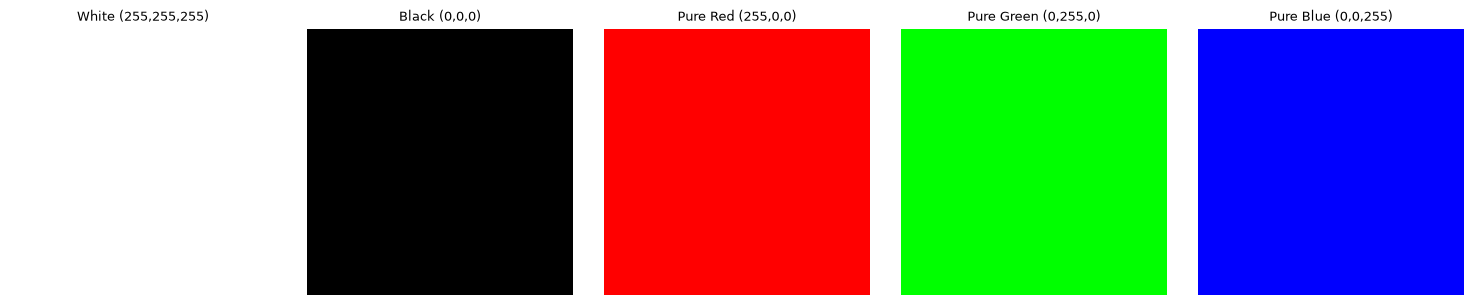

In [ ]:
# Create 5x5 RGB images with pure colors
white = np.full((5, 5, 3), 255, dtype=np.uint8)
black = np.zeros((5, 5, 3), dtype=np.uint8)
red = np.zeros((5, 5, 3), dtype=np.uint8); red[:, :, 0] = 255
green = np.zeros((5, 5, 3), dtype=np.uint8); green[:, :, 1] = 255
blue = np.zeros((5, 5, 3), dtype=np.uint8); blue[:, :, 2] = 255

images = [white, black, red, green, blue]
titles = ["White (255,255,255)", "Black (0,0,0)", "Pure Red (255,0,0)",
          "Pure Green (0,255,0)", "Pure Blue (0,0,255)"]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("pure_color_images.png")
plt.show()

In [7]:
# How many pixels have an intensity of 45?
count_45 = np.sum(arr[:, :, 0] == 45)
print(f"Pixels with intensity 45 (Red channel): {count_45}")

# Plot the hist for G and B
plt.hist(arr[:, :, 1].ravel(), bins=256, range=(0, 255))
plt.title("Green Channel Histogram")
plt.show()

plt.hist(arr[:, :, 2].ravel(), bins=256, range=(0, 255))
plt.title("Blue Channel Histogram")
plt.show()

NameError: name 'arr' is not defined

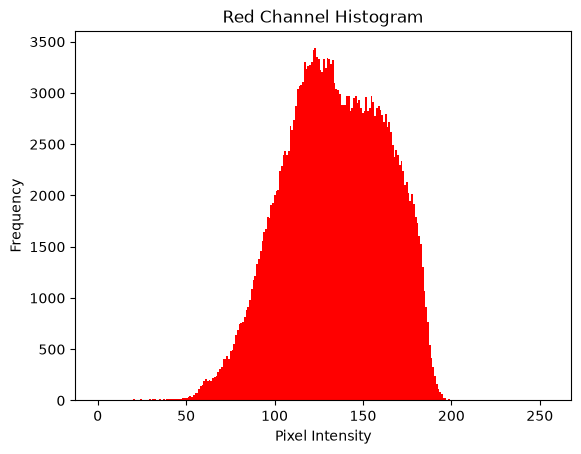

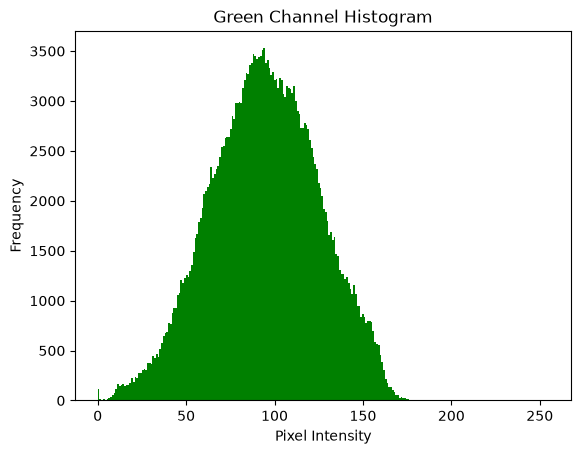

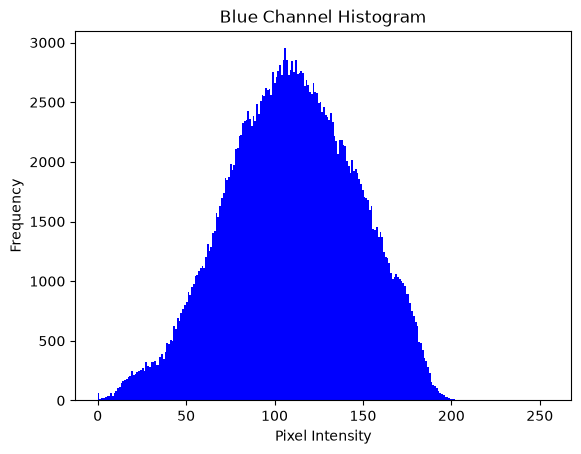

Pixels with intensity 45 - Red: 16
Pixels with intensity 45 - Green: 1061
Pixels with intensity 45 - Blue: 688


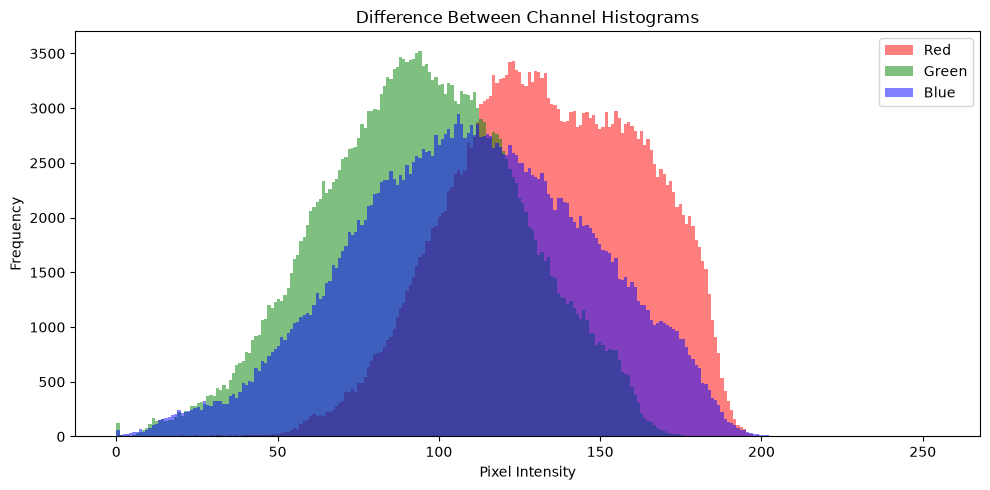


Red mean:   133.99
Green mean: 94.37
Blue mean:  109.63


In [10]:


# --- Histogram for Red channel ---
plt.hist(img_array[:, :, 0].ravel(), bins=256, range=(0, 255), color="red")
plt.title("Red Channel Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

# --- Histogram for Green channel ---
plt.hist(img_array[:, :, 1].ravel(), bins=256, range=(0, 255), color="green")
plt.title("Green Channel Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

# --- Histogram for Blue channel ---
plt.hist(img_array[:, :, 2].ravel(), bins=256, range=(0, 255), color="blue")
plt.title("Blue Channel Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

# --- How many pixels have an intensity of 45? ---
count_45_red = np.sum(img_array[:, :, 0] == 45)
count_45_green = np.sum(img_array[:, :, 1] == 45)
count_45_blue = np.sum(img_array[:, :, 2] == 45)
print(f"Pixels with intensity 45 - Red: {count_45_red}")
print(f"Pixels with intensity 45 - Green: {count_45_green}")
print(f"Pixels with intensity 45 - Blue: {count_45_blue}")

# --- Difference between channel histograms (overlaid) ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(img_array[:, :, 0].ravel(), bins=256, range=(0, 255), color="red", alpha=0.5, label="Red")
ax.hist(img_array[:, :, 1].ravel(), bins=256, range=(0, 255), color="green", alpha=0.5, label="Green")
ax.hist(img_array[:, :, 2].ravel(), bins=256, range=(0, 255), color="blue", alpha=0.5, label="Blue")
ax.set_title("Difference Between Channel Histograms")
ax.set_xlabel("Pixel Intensity")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

# --- Numeric comparison ---
print(f"\nRed mean:   {img_array[:, :, 0].mean():.2f}")
print(f"Green mean: {img_array[:, :, 1].mean():.2f}")
print(f"Blue mean:  {img_array[:, :, 2].mean():.2f}")

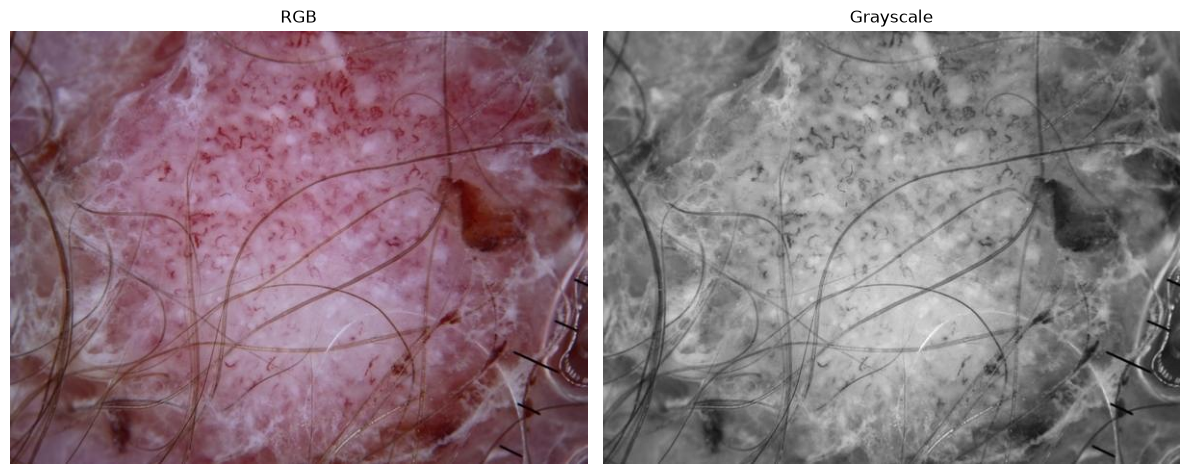

In [13]:
# Convert full image RGB to Grayscale
arr_gray = 0.299*img_array[:,:,0] + 0.587*img_array[:,:,1] + 0.114*img_array[:,:,2]
arr_gray = arr_gray.astype(np.uint8)

# Plot 2 subplots: RGB vs Grayscale
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_array)
axes[0].set_title("RGB")
axes[0].axis("off")

axes[1].imshow(arr_gray, cmap="gray")
axes[1].set_title("Grayscale")
axes[1].axis("off")

plt.tight_layout()
plt.show()

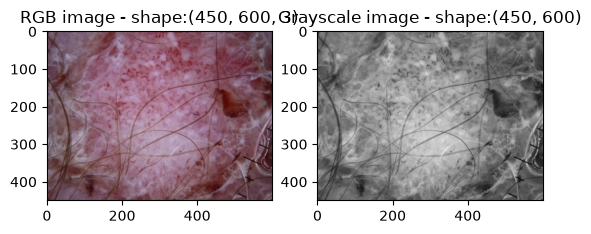

In [15]:
import cv2

arr_gray_cv2 = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

plt.subplot(1,2,1)
plt.imshow(img_array)
plt.title("RGB image - shape:" + str(img_array.shape))

plt.subplot(1,2,2)
plt.imshow(arr_gray_cv2, cmap='gray')
plt.title("Grayscale image - shape:" + str(arr_gray_cv2.shape))

plt.show()

In [17]:
# manual way using the luminosity formula
arr_gray_manual = (0.299 * img_array[:,:,0] + \
                    0.587 * img_array[:,:,1] + \
                    0.114 * img_array[:,:,2]).astype(np.uint8)

print(arr_gray_manual.shape)

(450, 600)


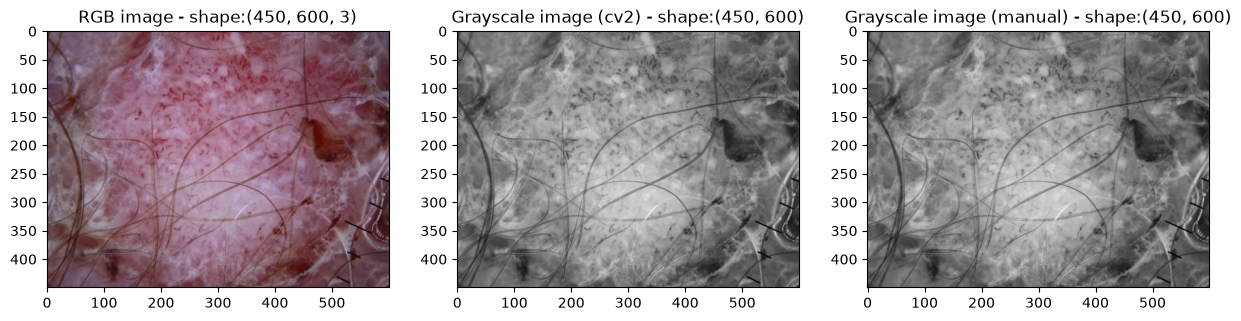

In [18]:
# manual way using the luminosity formula
arr_gray_manual = (0.299 * img_array[:,:,0] + \
                    0.587 * img_array[:,:,1] + \
                    0.114 * img_array[:,:,2]).astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1,3,1)
plt.imshow(img_array)
plt.title("RGB image - shape:" + str(img_array.shape))

plt.subplot(1,3,2)
plt.imshow(arr_gray_cv2, cmap='gray')
plt.title("Grayscale image (cv2) - shape:" + str(arr_gray_cv2.shape))

plt.subplot(1,3,3)
plt.imshow(arr_gray_manual, cmap='gray')
plt.title("Grayscale image (manual) - shape:" + str(arr_gray_manual.shape))

plt.show()

In [20]:
are_close = np.allclose(arr_gray_cv2, arr_gray_manual, atol=1)
print(f"Are cv2 and manual grayscale close? {are_close}")


Are cv2 and manual grayscale close? True
